In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from time import sleep
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import enrich_omics
from enrich_omics import EnrichR


In [84]:
# read data
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_ready.csv', header = 0, index_col=0)
clin = clin.drop(labels = [1578], axis = 0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/dataset_final_4979prot.csv', index_col = 0)

print(prot.shape)
print(clin.shape)

print("prot shape", prot.shape)
print("clin shape", clin.shape)

X = StandardScaler().fit_transform(prot)
df_scaled = pd.DataFrame(X)
df_scaled.columns = prot.columns
df_scaled.index = prot.index


kmeans = KMeans(n_clusters=20, random_state=0).fit(df_scaled.T)
colors = ["#e1dddd", "#ffcc00","#FF7000", "#9900ff", "#eae2b8","#ff748c", "#e7f6f8", "#7a2c52","#00f4ff","#023FF5","#ff00b4",
          "#f8e7e7","#95a355","#00cd00","#02B5F5","#999999", "#030789", "#8E543A","#a5682a","#e50000"]

palette_20 = sns.color_palette(colors)

#change it to 3 for the plots below
import matplotlib.patches as mpatches
clust0 = mpatches.Patch(color=palette_20[0], label='Cluster0')
clust1 = mpatches.Patch(color=palette_20[1], label='Cluster1')
clust2 = mpatches.Patch(color=palette_20[2], label='Cluster2')
clust3 = mpatches.Patch(color=palette_20[3], label='Cluster3')
clust4 = mpatches.Patch(color=palette_20[4], label='Cluster4')
clust5 = mpatches.Patch(color=palette_20[5], label='Cluster5')
clust6 = mpatches.Patch(color=palette_20[6], label='Cluster6')
clust7 = mpatches.Patch(color=palette_20[7], label='Cluster7')
clust8 = mpatches.Patch(color=palette_20[8], label='Cluster8')
clust9 = mpatches.Patch(color=palette_20[9], label='Cluster9')
clust10 = mpatches.Patch(color=palette_20[10], label='Cluster10')
clust11 = mpatches.Patch(color=palette_20[11], label='Cluster11')
clust12 = mpatches.Patch(color=palette_20[12], label='Cluster12')
clust13 = mpatches.Patch(color=palette_20[13], label='Cluster13')
clust14 = mpatches.Patch(color=palette_20[14], label='Cluster14')
clust15 = mpatches.Patch(color=palette_20[15], label='Cluster15')
clust16 = mpatches.Patch(color=palette_20[16], label='Cluster16')
clust17 = mpatches.Patch(color=palette_20[17], label='Cluster17')
clust18 = mpatches.Patch(color=palette_20[18], label='Cluster18')
clust19 = mpatches.Patch(color=palette_20[19], label='Cluster19')

tsne = TSNE(n_components=2, perplexity = 30, random_state=121).fit_transform(df_scaled.T) 

(414, 4979)
(414, 38)
prot shape (414, 4979)
clin shape (414, 38)


/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


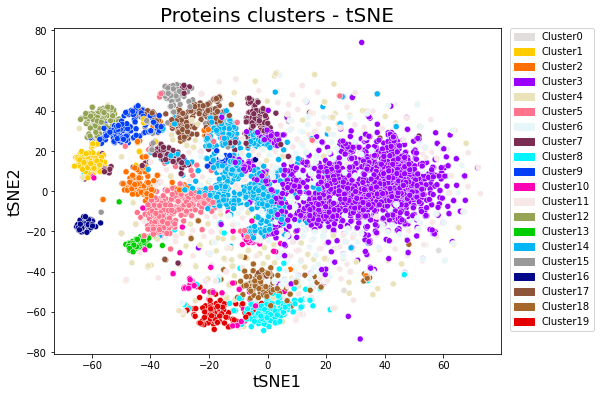

In [99]:
### something changes in the tsne code so we have to use the other dataset
old = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/tsne_coordinates.csv', index_col=0)

plt.figure(figsize = (8,6))
plt.title("Proteins clusters - tSNE", fontsize=20)
plt.xlabel("tSNE1", fontsize=16)
plt.ylabel("tSNE2", fontsize=16)
fig = sns.scatterplot(x = old.iloc[:,0], y = old.iloc[:,1], hue=kmeans.labels_, palette = palette_20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, handles=[clust0, clust1, clust2,
    clust3, clust4, clust5, clust6, clust7, clust8,clust9,clust10, clust11, clust12,clust13,clust14,
    clust15,clust16, clust17, clust18, clust19])


In [110]:
# functions for analysis
def plot_prot_per_cluster(labels, n):
    sns.barplot(x = pd.Series(labels).value_counts(normalize=False).index, 
    y=pd.Series(labels).value_counts(normalize=False), order =list(range(0, n))) 
    plt.axhline(y=50, color='r', linestyle='-')
    plt.axhline(y=400, color='r', linestyle='-')
    plt.title("Proteins in each cluster - k="+str(n))

# create funcs for enrichment
def create_clust_df(labels):
    clusters_df = pd.DataFrame(labels, columns =['KMeans_clusters'])
    clusters_df.index = prot.columns
    return clusters_df


def make_enrich_pathway(clusters_df, k):
    enrichment={}
    for i in range(len(clusters_df['KMeans_clusters'].unique())):
        idx = clusters_df[clusters_df['KMeans_clusters']==i].index
        idx = [element.split(".")[0] for element in idx]
        enrichment['cluster_n_{}'.format(i)] = idx

    # create a df
    pathways = pd.DataFrame()
    pathways['cluster'] = list(range(0,k))
    pathways['names'] = np.zeros(len(pathways))

    names=[]
    for i in range(len(enrichment)):
        sleep(0.3)
        curr_list = list(EnrichR.get_table_enrichment(enrichment['cluster_n_'+ str(i)])[0:2]['Term name'])
        names.append(curr_list)
    pathways['names'] = names
    
    return pathways


### Evaluating KMEANS 20

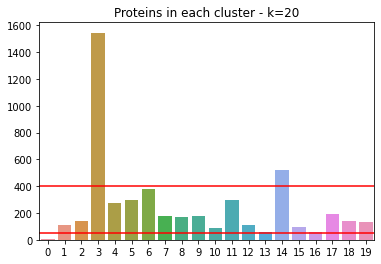

In [116]:
# we chose kmeans 20 because we get clusters that represent most of the pathways we are interested in
# also clusters are a way to identify changes and name the "areas" of the plot. Thus it does not really matter if they are 10 or 100

plot_prot_per_cluster(kmeans.labels_, 20)
plt.savefig('/Users/smasarone/Desktop/kmeans20.pdf', format = 'pdf')

In [112]:
### Cluster 3 is the only cluster with many proteins in it and it's very generic while all the others are quite specific
### We can see that most of the clusters have between 50 and 300 proteins allowing us to obtain decent clusters

from sklearn.metrics import silhouette_samples, silhouette_score
silhouette_avg = silhouette_score(df_scaled.T, kmeans.labels_)
print(silhouette_avg.round(2))

0.11


In [93]:
# checking func
df = create_clust_df(kmeans.labels_)
table = make_enrich_pathway(df, 20)

# export table
table.to_csv("table_20.csv")


### Evaluating KMEANS 10

sil score: 0.18


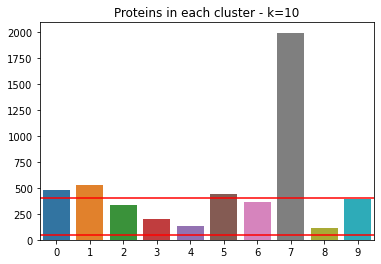

In [117]:
#traying with 10 clusters only
kmeans10 = KMeans(n_clusters=10, random_state=0).fit(df_scaled.T)
pd.Series(kmeans10.labels_).value_counts()


# plot clusters
plot_prot_per_cluster(kmeans10.labels_, 10)
plt.savefig('/Users/smasarone/Desktop/kmeans10.pdf', format = 'pdf')

silhouette_avg = silhouette_score(df_scaled.T, kmeans10.labels_)
print("sil score:", silhouette_avg.round(2))

In [96]:
df10 = create_clust_df(kmeans10.labels_)
table10 = make_enrich_pathway(df10, 10)

In [114]:
table10.to_csv("table10.csv")

### Evaluating KMEANS 30

In [77]:
#traying with 30 clusters 
kmeans30 = KMeans(n_clusters=30, random_state=0).fit(df_scaled.T)
pd.Series(kmeans30.labels_).value_counts(normalize=False)

silhouette_avg = silhouette_score(df_scaled.T, kmeans30.labels_)
print(silhouette_avg)

0.08602688945135935


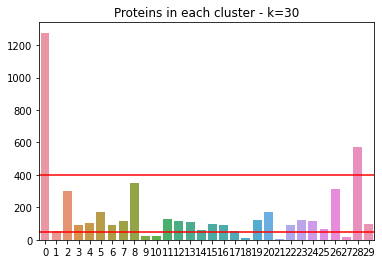

In [119]:
plot_prot_per_cluster(kmeans30.labels_, 30)
plt.savefig('/Users/smasarone/Desktop/kmeans30.pdf', format = 'pdf')

In [98]:
df30 = create_clust_df(kmeans30.labels_)
table = make_enrich_pathway(df30, 30)

In [81]:
table 

,cluster,names
0,0,"[Cytokine-cytokine receptor interaction, JAK-S..."
1,1,[Viral protein interaction with cytokine and c...
2,2,"[JAK-STAT signaling pathway, PI3K-Akt signalin..."
3,3,"[Antigen processing and presentation, Drug met..."
4,4,"[Focal adhesion, Platelet activation]"
5,5,"[Chronic myeloid leukemia, ErbB signaling path..."
6,6,"[Cytokine-cytokine receptor interaction, Viral..."
7,7,"[ECM-receptor interaction, Phagosome]"
8,8,"[Cytokine-cytokine receptor interaction, Kapos..."
9,9,"[Pancreatic secretion, Salivary secretion]"


In [ ]:
### Final thoughts on this
# we iterated through different ks (10, 20, 30) to get a useful number of clusters toperform downstream analysis. \
# The cluster themselves are not there to say how similar or dissimilar proteins are, but to provide a framework to refer to identify what proteins 
# change in expression as severity changes (or as different outcomes occur)
# in this context, the number itself is not that important. What matters more is the size of the clusters we identify. Clusters that are too small are not \
# particularly useful and can bee too granular, while clusters that are too big tend to give enrichment results that are too vague \
# we find that k = 20 gives us clusters that are reasonably sized.

